with regression we're trying to predict a singular value that is a total

with multi-class problems (mainly image classification) or one of n categories an observation belongs to. 

If we can predict a quantitative value then avoid bucketing (avoid turning the problem into a categorical classification problem)

sometimes we have no predictive power with a quantitative linear model so then bucketing is preferred

logistic regression
linear regression fails on binary classification because the line of best fit doesn't have enough normally distributed observations to have a meaningful model

instead we want to find a function that captures the pattern much better

This is model based (want a mathematical formula because they're interpretable and tell the relationship between independent variables with the dependent) in math and has a line with a formula which is a benefit. instance based learning don't have functions (clustering) and that's why they're computationally expensive. 

Logistic regression is a regressed (quantitative) output and it is a probability (0-1) and is a continuous data point. Most logistic regression models classify on a 50% threshold. This can be adjusted using threshold tuning. Tuning the classification threshold i can set the probability required to classify an observation as 1 or not. It is not a model optimization technique, but it will toggle between precision and recall. This is one way to improve the precision-recall tradeoff but must decide which metric I want to optimize for. 

Because it is a linear model it still falls victim to multicollinearity and autocorrelation (i could get coefficients from an interpretability standpoint will be an issue with this model). any treatment id apply to linear regression models to fix this issue i can apply to logistic regression models.

**For example, a multi-output problem:**

y is 4 options and we want to decide the likelihood an output is picked. Logistic regression in its base format is only a binary model. Logistic regression is adequate for multiclass problems and performs better than instance based models. will get a diverse range of proxy-probabilities (more extreme ends) when using instance based probabilities compared to logistic regression which has better estimation and gives real probabilities.

When running a multi-class model it is actually several models (n-1) and these models are trained against a baseline model. interpret the probabilities as how much higher or lower is this probability compared to the baseline. Versus the baseline, how much higher/lower is that probability - say category 4 is the baseline, how much higher or lower is the probability being in category 1 (then 2, then 3) than being in category 4.

All of the probabilities will sum to one. Similar to deep learning models

softmax normalization is used by scikit learn and most other tools (and it isn't using the baseline method of multiclass probability prediction). Softmax builds 4 (however many categories) unique models organically so we get the probability of every single category. still have to divide the probabilities by the total probabilty so the total probability sums up to 1. 

softmax is more efficient and easier to implement so it is used everywhere

In the background, once y is set and it is multi-categories, the model creates dummy variables (4 columns of the y array). 

Coefficients are estimated using MLE and is found by numerical optimizatio methods: newton-cg and LBFGS (better for larger data sets but won't be as granular). These solvers are not adaptive (can only adjust the learning rate ie: how big of a step should I take in this direction). Ascent algorithms. (Minimizing loss functions is the opposite)

Gradient descent is a very inefficient solver. Gradient boosting algorithm isn't great for production because of its slow optimizatio methods. 

Adam is a deep learning optimizer (most advance solver that exists in traditional ML because it is adaptive)

what makes data science hard is the compute and the computation. some of these computations aren't very easy for computers to process (this is the core of ML research ie: how do we use different techniques to make compute faster. the more efficient models are the better). 

beta is interpreted is how much of the probability increase or decrease with each additional 1 unit change. Same interpretation as lienar regression (can be used to determine the most important features).

Model assessment is typically done with precision-recall. Can't calculate precision-recall on a multi-class problem but can compute the confusion matrix (look at where the model is weak and is useful because i can identify where it is predicting incorrectly. A good way to find where the model is weak or where it is not. It is the best tool to use)

medical tests (healthcare analytics) prioritize recall over precision 

f1 score is just a balanced score of how a model handles both precision-recall curve (if you care about both then this is the metric to optimize) but Delina recommends to not do this

If we have data imbalance (which is the case for most data), then I should pick either precision or recall to optimize because I'll get a better result than trying to optimize both

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

In [2]:
X, y = load_iris(return_X_y=True)
iris_df = pd.DataFrame(X, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
iris_df['target'] = y

In [ ]:
iris_df # multi-class problem

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


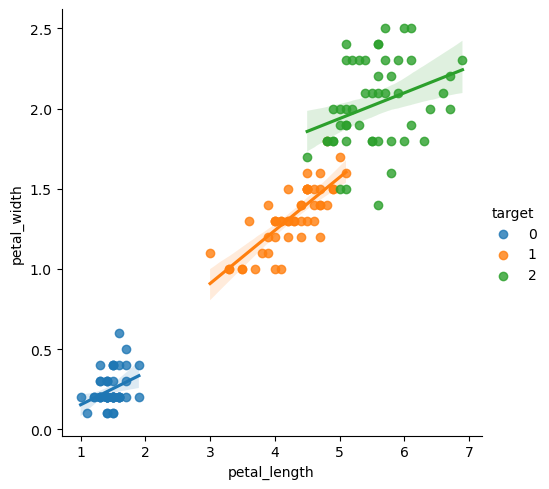

In [ ]:
import seaborn as sns
# delina recommends just visualizing your data to see which models would be good to use, upfront work to make sure things will go as expected

sns.lmplot(iris_df, x='petal_length', y='petal_width', hue='target') # quick plot that plots quick regression lines from seaborn
# it is a good indicator if my problem is predictable
# if the features have a lot of overlap then any model would have trouble classifiying

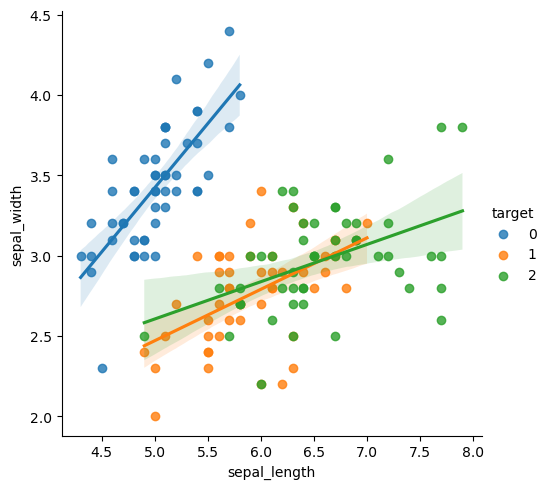

In [5]:
sns.lmplot(iris_df, x='sepal_length', y='sepal_width', hue='target') 
# if i didnt have petal measurements only sepal then my model wouldn't be able to distinguish between category 1 and 2

In [6]:
model = LogisticRegression(random_state = 0, max_iter = 1000).fit(X,y)

In [7]:
model.intercept_ # all of my intercept values from the model

array([  9.85644712,   2.23072008, -12.0871672 ])

In [ ]:
model.coef_ # all of my coefficients of each of the features for each of the distinct models
# this is used for feature importance or direction; this is how much it increases the odds
# the first model predicts setosa as the 1st category - the bigger the length of the sepals the less likely it is to be a setosa, the wider the sepal is the more likely it is setosa, longer the petals or wider the petals are the less likely it is to be setosa
# softmax is used 

array([[-0.42443936,  0.96633079, -2.51584831, -1.0821654 ],
       [ 0.53500627, -0.31995254, -0.20692068, -0.94360998],
       [-0.1105669 , -0.64637825,  2.72276899,  2.02577538]])

In [9]:
# getting the predictions
model.predict_proba(X) # this will get me the actual probabilties
# because i ahve three outputs ill get 3 probabilities 
# there is a 98% chance it is a setosa flower (0), 1.8% category 1, and 0.00000144% category 2

array([[9.81554832e-01, 1.84451535e-02, 1.44826938e-08],
       [9.71337452e-01, 2.86625174e-02, 3.01465503e-08],
       [9.85271334e-01, 1.47286537e-02, 1.23189114e-08],
       [9.76075836e-01, 2.39241245e-02, 3.96212634e-08],
       [9.85210070e-01, 1.47899185e-02, 1.19892842e-08],
       [9.70131407e-01, 2.98685186e-02, 7.39581601e-08],
       [9.86765086e-01, 1.32348941e-02, 1.99529556e-08],
       [9.76124995e-01, 2.38749778e-02, 2.76922493e-08],
       [9.79651240e-01, 2.03487293e-02, 3.05366580e-08],
       [9.68770778e-01, 3.12291900e-02, 3.16652966e-08],
       [9.76174051e-01, 2.38259295e-02, 1.93547737e-08],
       [9.75198920e-01, 2.48010358e-02, 4.38726283e-08],
       [9.74241209e-01, 2.57587695e-02, 2.14746712e-08],
       [9.91880100e-01, 8.11989595e-03, 3.88178868e-09],
       [9.87962896e-01, 1.20371014e-02, 2.84366700e-09],
       [9.86582922e-01, 1.34170646e-02, 1.29409814e-08],
       [9.87921745e-01, 1.20782454e-02, 9.26482124e-09],
       [9.81302292e-01, 1.86976

In [ ]:
model.predict(X) # these are the predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
confusion_matrix(y, model.predict(X))
# no mistakes for category 1
# 3 false positive predictions for category 3 where they are category 2
# 1 false negative prediction for category 2 where they are category 3

array([[50,  0,  0],
       [ 0, 47,  3],
       [ 0,  1, 49]])

In [ ]:
# can manually calculate the average precision/recall of the 3 models for this multi-class problem
precision_score(y, model.predict(X), average='weighted') # weighted averaging is the best method to use for an accurate understanding


0.9738247863247864

In [13]:
recall_score(y, model.predict(X), average='weighted')

0.9733333333333334

In [16]:
f1_score(y, model.predict(X), average='weighted')

0.9733226623982927

In [ ]:
# can create polynomial features to fit a curve instead of a line
# adding interaction terms can add multicollinearity
# other classifiers besides logistic regression and variations are instance based (or naive bayes but it is too simple)